In [1]:
import numpy as np
import matplotlib.pyplot as plt

L'obiettivo è visualizzare le distribuzioni delle frazioni di eventi per le diverse feautures per segnale e rumore sovrapposte.

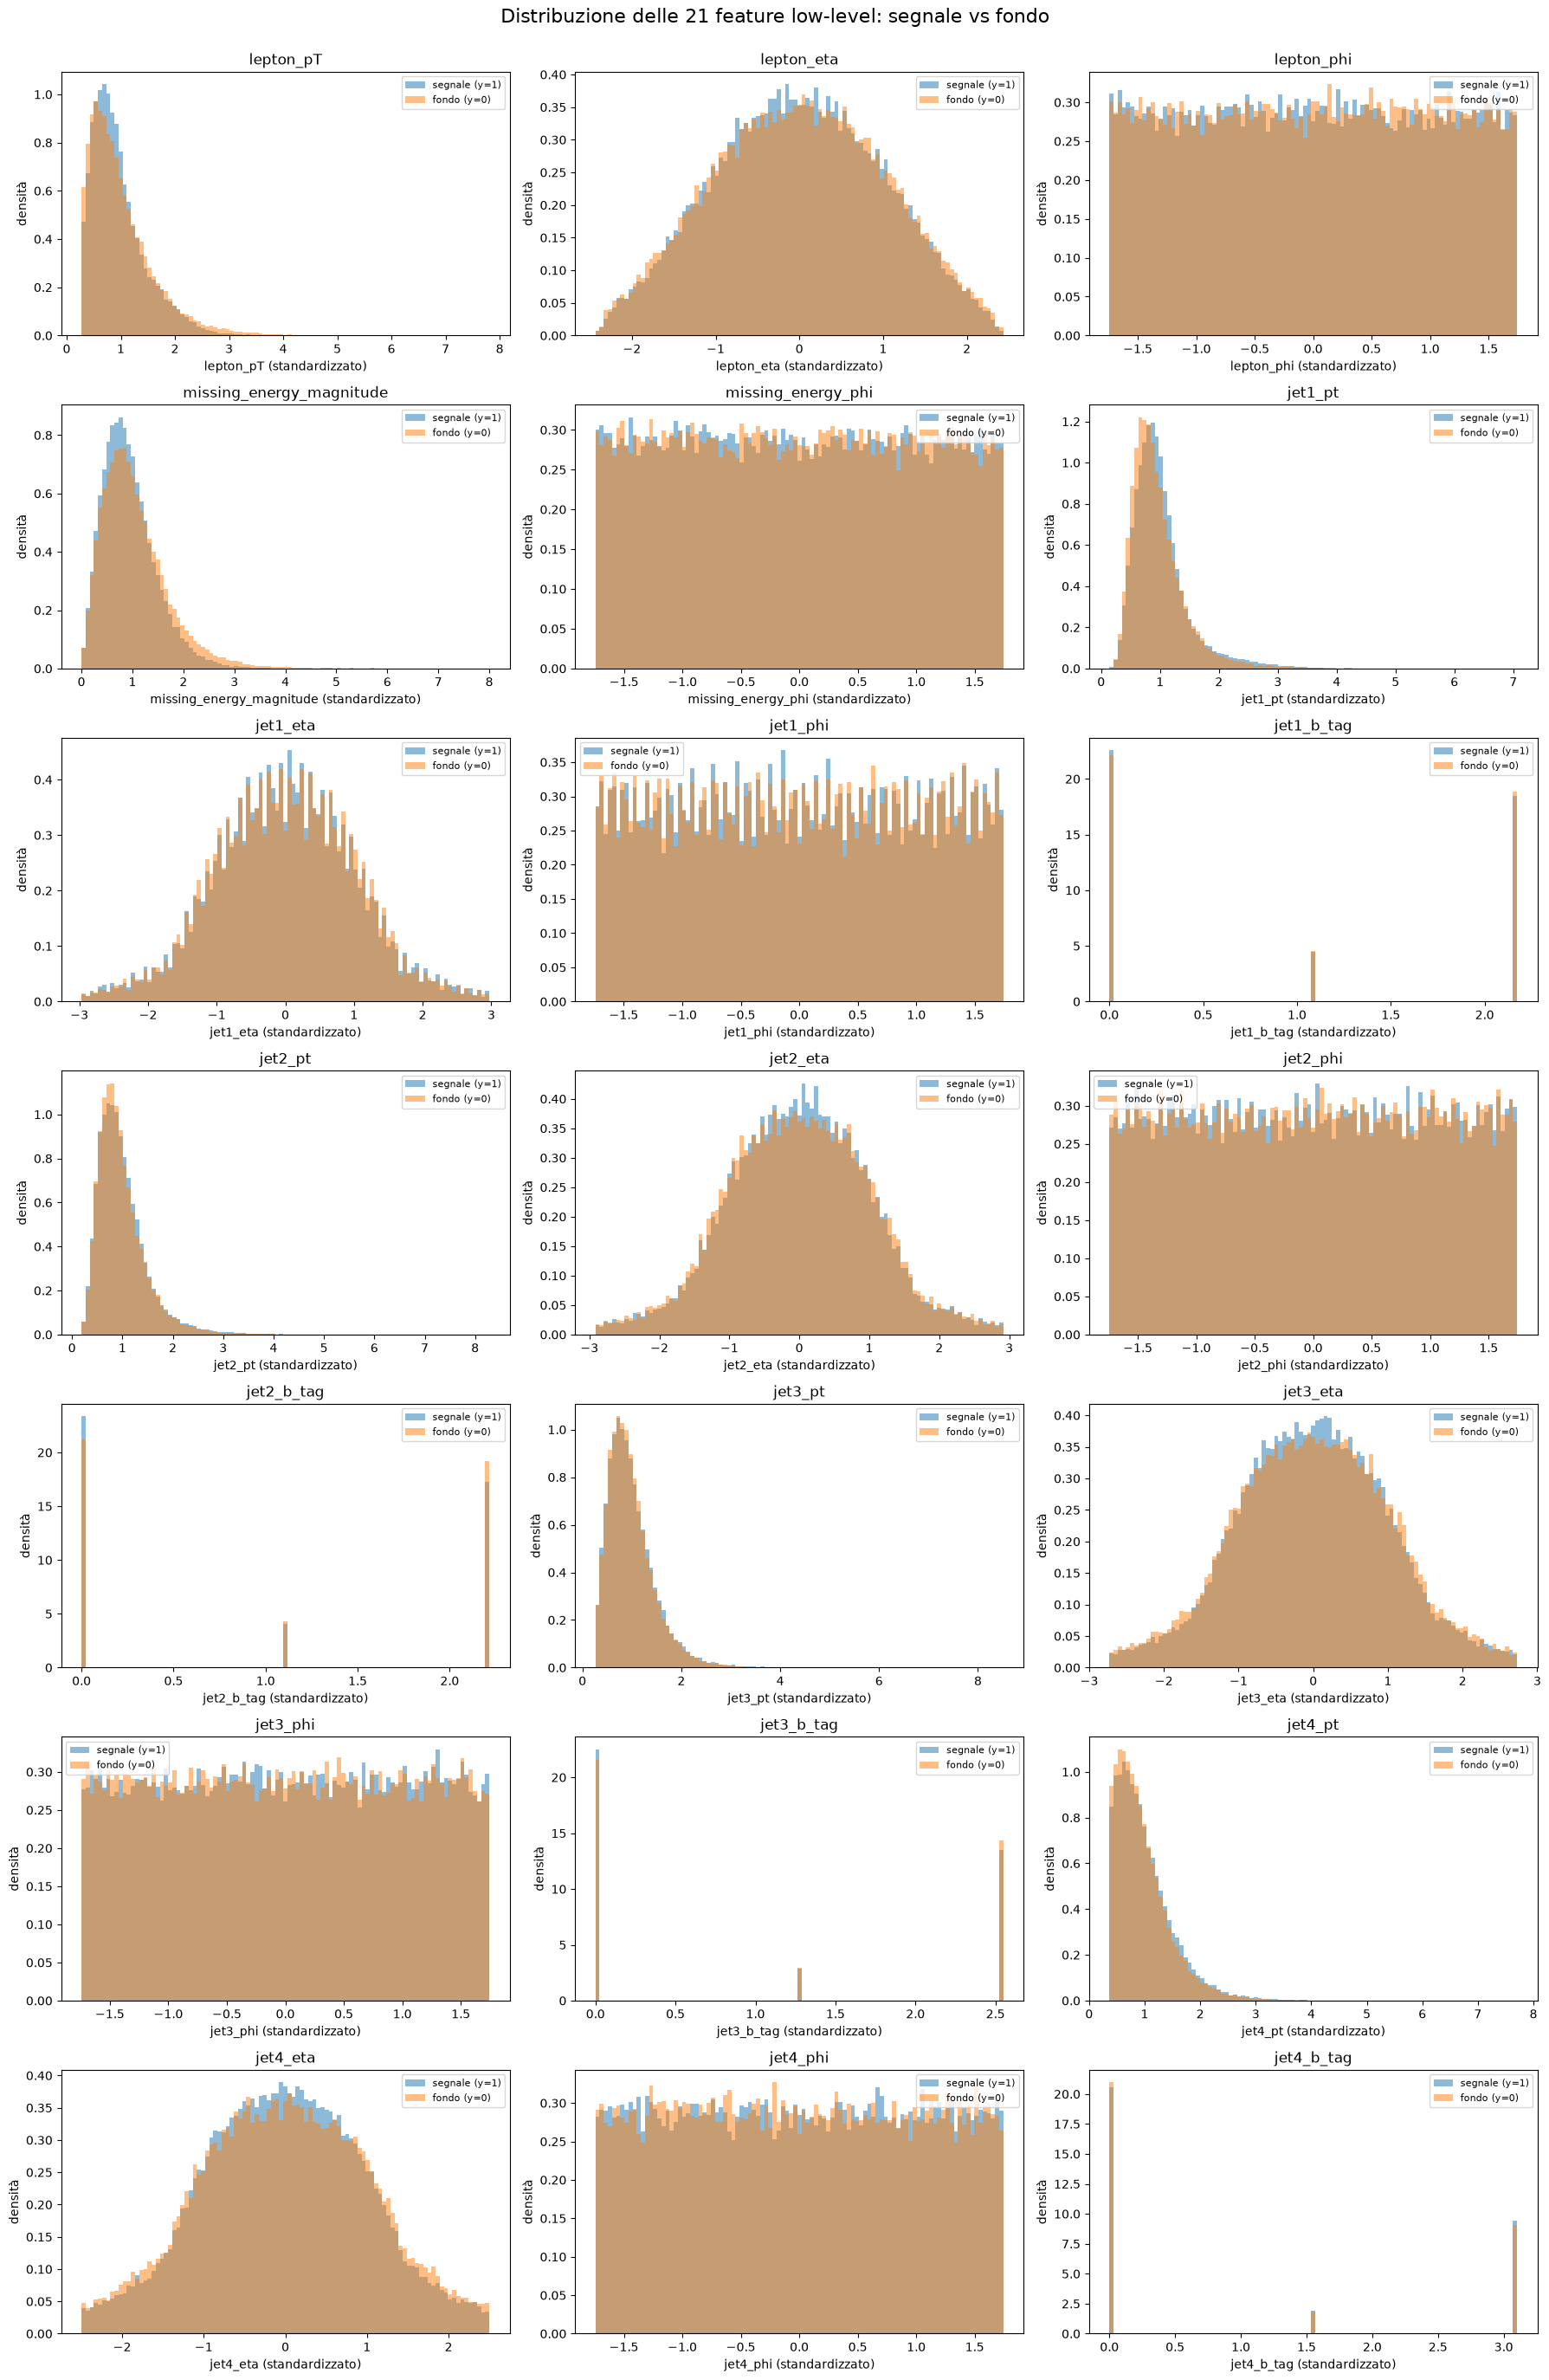

In [3]:
X = np.load("../data/processed_small/X.npy")
y = np.load("../data/processed_small/y.npy").ravel()

lepton_pT = X[:, 0]  # colonna 0 = lepton_pT (vedi src/features.py)

segnale = lepton_pT[y == 1]
fondo = lepton_pT[y == 0]

import sys
sys.path.append("..")
from src.features import LOW_LEVEL

segnale_all = X[y == 1]
fondo_all = X[y == 0]

fig, axes = plt.subplots(7, 3, figsize=(18, 28))


for i, (ax, nome) in enumerate(zip(axes.flat, LOW_LEVEL)):
    col = X[:, i]
    bins = np.linspace(col.min(), col.max(), 100)

    ax.hist(segnale_all[:, i], bins=bins, alpha=0.5, density=True, label="segnale (y=1)")
    ax.hist(fondo_all[:, i], bins=bins, alpha=0.5, density=True, label="fondo (y=0)")
    ax.set_title(nome)
    ax.set_xlabel(nome + " (standardizzato)")
    ax.set_ylabel("densità")
    ax.legend(fontsize=8)

fig.suptitle("Distribuzione delle 21 feature low-level: segnale vs fondo", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()




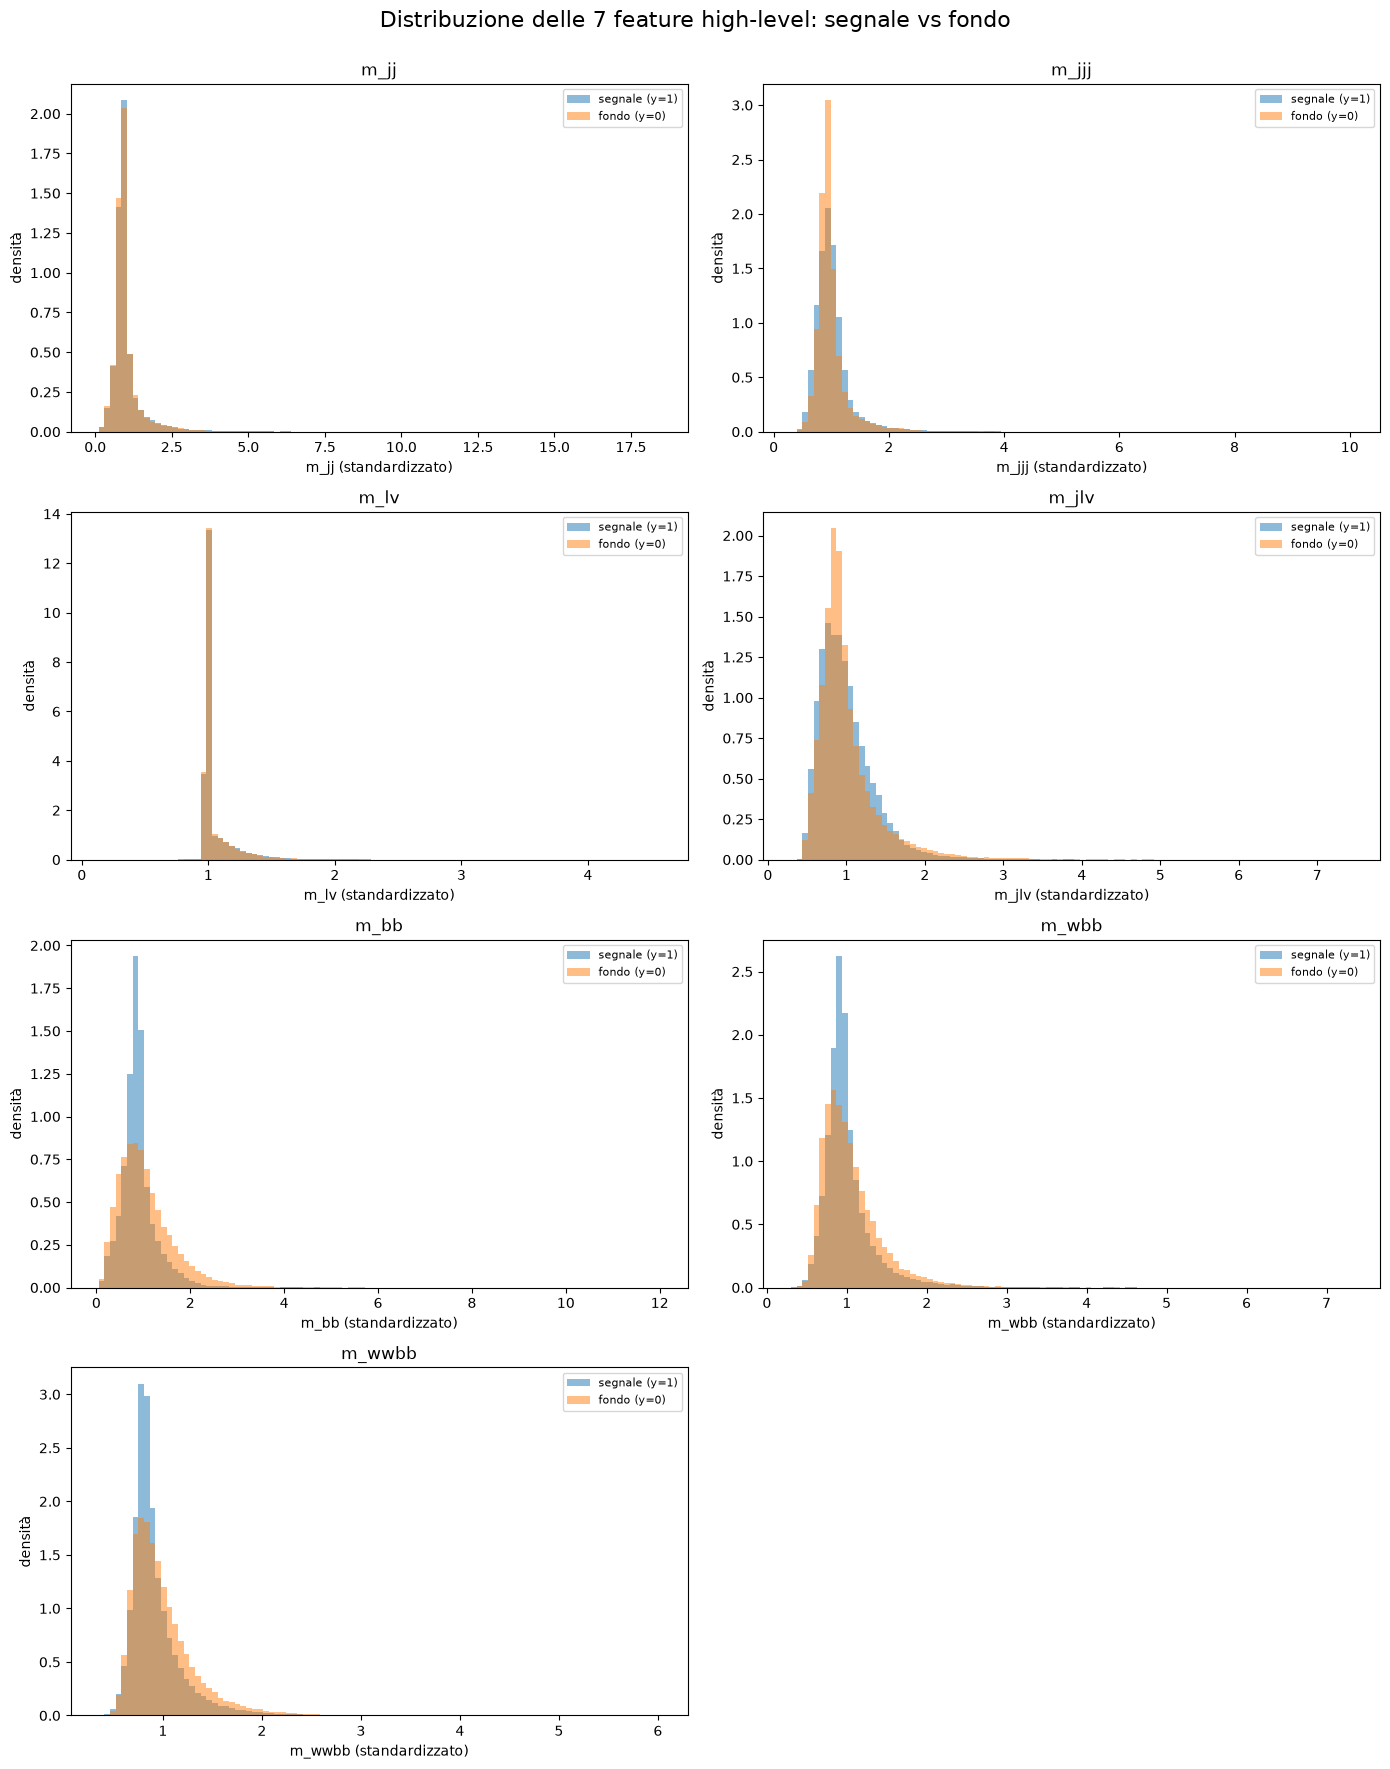

In [4]:
from src.features import HIGH_LEVEL

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, (ax, nome) in enumerate(zip(axes.flat, HIGH_LEVEL)):
    col_idx = 21 + i  # le 7 feature high-level sono le colonne 21-27 di X
    col = X[:, col_idx]
    bins = np.linspace(col.min(), col.max(), 100)

    ax.hist(segnale_all[:, col_idx], bins=bins, alpha=0.5, density=True, label="segnale (y=1)")
    ax.hist(fondo_all[:, col_idx], bins=bins, alpha=0.5, density=True, label="fondo (y=0)")
    ax.set_title(nome)
    ax.set_xlabel(nome + " (standardizzato)")
    ax.set_ylabel("densità")
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")  # l'ottavo subplot resta vuoto (solo 7 feature)

fig.suptitle("Distribuzione delle 7 feature high-level: segnale vs fondo", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()